In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
import cv2
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Model planning:
1. Plain CNN 1 ()
2. Deeper + Higher receptive field
3. Resnet18 encoder -> U-Net/FPN

# Loss:

In [2]:
class HeatmapCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=2, dilation=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.head = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, 1)  # logits: channel 0=interior, channel 1=edge
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.head(x)
        return x


# Instantiate model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeatmapCNN().to(DEVICE)
print(f'Model on device: {DEVICE}')
print(model)

Model on device: cuda
HeatmapCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Conv2d(256, 64, kernel_size=(3, 3), st

In [3]:
# 2-channel segmentation setup: channel 0=interior, channel 1=edge
criterion = nn.BCEWithLogitsLoss(reduction='none')

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


def total_variation_loss(x):
    """Small smoothness regularizer to reduce speckle noise in predicted masks."""
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def compute_segmentation_loss(
    logits,
    target,
    interior_weight=1.0,
    edge_weight=2.0,
    lambda_tv=2e-5,
):
    """BCE logits loss on two channels + tiny TV regularization on probabilities."""
    pixel_loss = criterion(logits, target)  # [B,2,H,W]
    ch_w = torch.tensor([interior_weight, edge_weight], device=logits.device, dtype=logits.dtype).view(1, 2, 1, 1)
    bce_loss = (pixel_loss * ch_w).mean()

    probs = torch.sigmoid(logits)
    tv_loss = total_variation_loss(probs)

    loss = bce_loss + lambda_tv * tv_loss
    return loss, bce_loss.detach(), tv_loss.detach()


def train_one_epoch(model, dataloader, optimizer, device, scaler=None, use_amp=False):
    model.train()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = images.to(device)   # [B,1,H,W]
        targets = targets.to(device) # [B,2,H,W]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)

        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Batch {batch_idx + 1}: total={loss.item():.4f}, bce={bce_l.item():.4f}, tv={tv_l.item():.4f}")

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }


class DummyHeatmapDataset(Dataset):
    def __init__(self, num_samples=16, img_size=256):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(1, self.img_size, self.img_size)
        target = torch.randint(0, 2, (2, self.img_size, self.img_size)).float()
        return image, target


def smoke_test_train_step(model, device):
    dummy_ds = DummyHeatmapDataset(num_samples=16, img_size=256)
    dummy_loader = DataLoader(dummy_ds, batch_size=4, shuffle=True)
    print("Smoke-test: running 1 epoch on dummy data...")
    metrics = train_one_epoch(model, dummy_loader, optimizer, device)
    print(f"Smoke-test metrics -> loss={metrics['loss']:.4f}, bce={metrics['bce']:.4f}, tv={metrics['tv']:.4f}")


# Uncomment to run a quick sanity check
# smoke_test_train_step(model, DEVICE)

In [4]:
PROJECT_ROOT = Path.cwd().parent.parent.resolve()
IMGS_DIR = PROJECT_ROOT / "data" / "imgs_contrast"
MASKS_DIR = PROJECT_ROOT / "data" / "masks"

assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"
assert MASKS_DIR.exists(), f"Missing folder: {MASKS_DIR}"

def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)

def build_two_channel_target(mask: np.ndarray) -> np.ndarray:
    """
    Returns HxWx2 target:
      channel 0: interior (1 inside cell, 0 background)
      channel 1: edge (1 on boundary pixels, 0 elsewhere)
    """
    m = (mask > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel)

    interior = m.astype(np.float32)
    edge = (edge > 0).astype(np.float32)

    target = np.stack([interior, edge], axis=-1)  # HxWx2
    return target

class CellHeatmapDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

        # Build mask lookup by stem
        mask_paths = list(MASKS_DIR.glob("*.tif"))
        self.mask_by_stem = {p.stem: p for p in mask_paths}

        # Keep only image paths with matching mask
        self.pairs = [(p, self.mask_by_stem[p.stem]) for p in self.img_paths if p.stem in self.mask_by_stem]
        if len(self.pairs) == 0:
            raise RuntimeError("No matched image/mask pairs found between imgs_contrast and masks.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path)              # HxW
        mask = tiff.imread(mask_path)            # HxW labels

        img = normalize01(img)
        target = build_two_channel_target(mask)  # HxWx2

        if self.transform is not None:
            aug = self.transform(image=img, mask=target)
            image = aug["image"]
            target = aug["mask"]
        else:
            image = torch.from_numpy(img).unsqueeze(0)      # [1,H,W]
            target = torch.from_numpy(target)               # [H,W,2]

        if isinstance(target, np.ndarray):
            target = torch.from_numpy(target)

        # Ensure CHW target -> [2,H,W]
        if target.ndim == 3 and target.shape[-1] == 2:
            target = target.permute(2, 0, 1)
        elif target.ndim == 3 and target.shape[0] == 2:
            pass
        else:
            raise RuntimeError(f"Unexpected target shape: {tuple(target.shape)}")

        return image.float(), target.float()

# Albumentations pipelines
train_tf = A.Compose([
    A.Resize(512, 512),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(0.9, 1.1),                 # slight zoom in/out
        translate_percent=(0.05, 0.05),   # ±5% shift in x/y
        rotate=(-30, 30),                 # continuous rotation
        shear=(-5, 5),                    # mild shear
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),

    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

# Collect all candidate images
all_img_paths = sorted(IMGS_DIR.glob("*.tif"))
if len(all_img_paths) == 0:
    raise RuntimeError(f"No images found in {IMGS_DIR}")

# Build base dataset once (no transform) to get matched pairs count
base_ds = CellHeatmapDataset(all_img_paths, transform=None)
n_total = len(base_ds)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val

# Split indices reproducibly
g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_ds, [n_train, n_val], generator=g)

# Re-wrap with transforms using the selected file pairs
train_img_paths = [base_ds.pairs[i][0] for i in train_subset.indices]
val_img_paths = [base_ds.pairs[i][0] for i in val_subset.indices]

train_dataset = CellHeatmapDataset(train_img_paths, transform=train_tf)
val_dataset = CellHeatmapDataset(val_img_paths, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Matched pairs total: {n_total}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)            # [B,1,H,W]
print("Batch target shape:", y.shape)           # [B,2,H,W]
print("Interior range:", float(y[:, 0].min()), float(y[:, 0].max()))
print("Edge range:", float(y[:, 1].min()), float(y[:, 1].max()))

Matched pairs total: 127
Train: 102 | Val: 25
Batch image shape: torch.Size([8, 1, 512, 512])
Batch target shape: torch.Size([8, 2, 512, 512])
Interior range: 0.0 1.0
Edge range: 0.0 1.0


In [5]:
from pathlib import Path
import time
import inspect
import torch


@torch.no_grad()
def validate_one_epoch(model, dataloader, device, use_amp=False):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)
        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    *,
    num_epochs=50,
    ckpt_dir=None,
    patience=10,
    min_delta=0.0,
    use_amp=True,
 ):
    if ckpt_dir is None:
        ckpt_dir = PROJECT_ROOT / "checkpoints" / "heatmapcnn"
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
    print(f"AMP enabled: {amp_enabled}")

    best_val = float('inf')
    best_path = ckpt_dir / "best_model.pth"
    last_path = ckpt_dir / "last_model.pth"
    log_path = ckpt_dir / "train_log.csv"

    wait = 0
    t0 = time.time()

    if not log_path.exists():
        log_path.write_text(
            "epoch,train_loss,val_loss,train_bce,val_bce,train_tv,val_tv,lr\n",
            encoding="utf-8",
        )

    has_scaler_arg = "scaler" in inspect.signature(train_one_epoch).parameters

    for epoch in range(1, num_epochs + 1):
        if has_scaler_arg:
            train_m = train_one_epoch(model, train_loader, optimizer, device, scaler=scaler, use_amp=amp_enabled)
        else:
            train_m = train_one_epoch(model, train_loader, optimizer, device)

        val_m = validate_one_epoch(model, val_loader, device, use_amp=amp_enabled)

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_m["loss"])
        else:
            scheduler.step()

        lr = optimizer.param_groups[0].get("lr", float('nan'))
        elapsed_min = (time.time() - t0) / 60.0
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train={train_m['loss']:.4f} | val={val_m['loss']:.4f} | "
            f"lr={lr:.2e} | {elapsed_min:.1f} min"
        )

        torch.save(model.state_dict(), last_path)

        if val_m["loss"] < (best_val - min_delta):
            best_val = val_m["loss"]
            wait = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved best: {best_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping: no val improvement in {patience} epochs")
                break

        with log_path.open("a", encoding="utf-8") as f:
            f.write(
                f"{epoch},{train_m['loss']:.6f},{val_m['loss']:.6f},"
                f"{train_m['bce']:.6f},{val_m['bce']:.6f},"
                f"{train_m['tv']:.6f},{val_m['tv']:.6f},"
                f"{lr:.8e}\n"
            )

    return {"best_val_loss": best_val, "best_path": str(best_path), "last_path": str(last_path), "log_path": str(log_path)}


In [24]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=50,
    patience=10,
 )
print(run_info)

AMP enabled: True


KeyboardInterrupt: 

In [6]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=300,
    patience=10,
 )
print(run_info)

AMP enabled: True
Batch 10: total=0.1003, bce=0.1003, tv=0.0027
Epoch 001/300 | train=0.3031 | val=0.0898 | lr=1.00e-03 | 0.2 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.2058, bce=0.2058, tv=0.0035
Epoch 002/300 | train=0.1734 | val=0.1040 | lr=1.00e-03 | 0.3 min
Batch 10: total=0.0818, bce=0.0818, tv=0.0057
Epoch 003/300 | train=0.1382 | val=0.0864 | lr=1.00e-03 | 0.5 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.1887, bce=0.1887, tv=0.0064
Epoch 004/300 | train=0.1222 | val=0.0793 | lr=1.00e-03 | 0.6 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0961, bce=0.0961, tv=0.0049
Epoch 005/300 | train=0.1254 | val=0.0766 | lr=1.00e-03 | 0.7 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0547, bce=0.0547, tv=0.0053
Epoch 006/300 | train=0.1221 | val=0.0766 | lr=1.00e-03 | 0.9 min
Batch 10: total=0.1492, bce=0.1492, tv=0.0071
Epoch 007/300 | trai

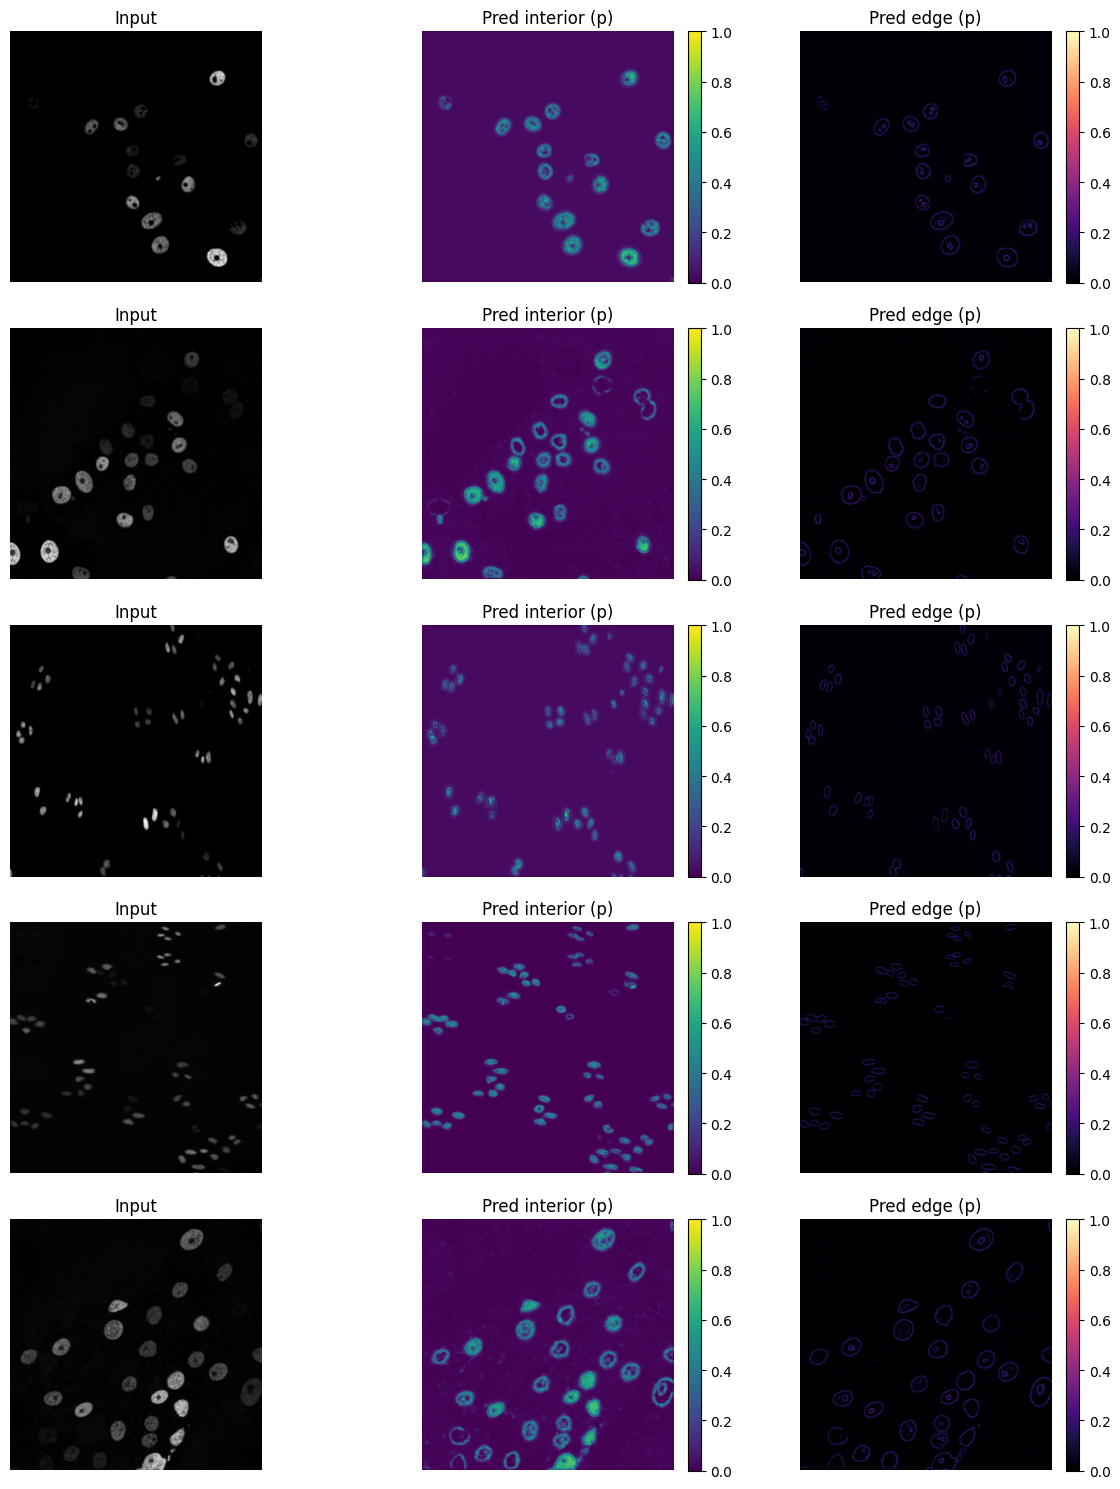

In [9]:
# Testing and visualization
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def show_predictions(model, dataloader, device, num_samples=3):
    """Plot examples: input, interior prob, edge prob."""
    model.eval()

    examples = []
    for images, _targets in dataloader:
        images = images.to(device)
        logits = model(images)                       # [B,2,H,W]
        probs = torch.sigmoid(logits).detach().cpu()
        images_cpu = images.detach().cpu()

        for i in range(images_cpu.shape[0]):
            img_hw = images_cpu[i, 0].numpy()
            interior_hw = probs[i, 0].numpy()
            edge_hw = probs[i, 1].numpy()
            examples.append((img_hw, interior_hw, edge_hw))
            if len(examples) >= num_samples:
                break
        if len(examples) >= num_samples:
            break

    if len(examples) == 0:
        raise RuntimeError("No samples found in dataloader.")

    fig, axes = plt.subplots(len(examples), 3, figsize=(12, 3 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for row, (img_hw, interior_hw, edge_hw) in enumerate(examples):
        ax_in, ax_int, ax_edge = axes[row]

        ax_in.imshow(img_hw, cmap="gray")
        ax_in.set_title("Input")
        ax_in.axis("off")

        im1 = ax_int.imshow(interior_hw, cmap="viridis", vmin=0.0, vmax=1.0)
        ax_int.set_title("Pred interior (p)")
        ax_int.axis("off")
        fig.colorbar(im1, ax=ax_int, fraction=0.046, pad=0.04)

        im2 = ax_edge.imshow(edge_hw, cmap="magma", vmin=0.0, vmax=1.0)
        ax_edge.set_title("Pred edge (p)")
        ax_edge.axis("off")
        fig.colorbar(im2, ax=ax_edge, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


show_predictions(model, train_loader, DEVICE, num_samples=5)

# Prompt generation algorithm with CNN

In [10]:
# Loads last checkpoint
# Runs through the whole train set, and saves preds and masks to a folder
from pathlib import Path
import numpy as np
import torch
import tifffile as tiff

# 1) Load checkpoint (prefer last, fallback to best)
ckpt_dir = PROJECT_ROOT / "checkpoints" / "heatmapcnn"
last_ckpt = ckpt_dir / "last_model.pth"
best_ckpt = ckpt_dir / "best_model.pth"

if last_ckpt.exists():
    ckpt_path = last_ckpt
elif best_ckpt.exists():
    ckpt_path = best_ckpt
else:
    raise FileNotFoundError(
        f"No checkpoint found in {ckpt_dir}. Expected one of: {last_ckpt.name}, {best_ckpt.name}"
    )

state_dict = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()
print(f"Loaded checkpoint: {ckpt_path}")

# 2) Build deterministic train inference dataset (no random aug)
train_infer_dataset = CellHeatmapDataset(train_img_paths, transform=val_tf)

# 3) Output folders
out_root = PROJECT_ROOT / "data" / "train_predictions"
pred_interior_dir = out_root / "pred" / "interior"
pred_edge_dir = out_root / "pred" / "edge"
mask_dir = out_root / "mask"
pred_interior_dir.mkdir(parents=True, exist_ok=True)
pred_edge_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)

# 4) Inference + save
with torch.no_grad():
    for idx in range(len(train_infer_dataset)):
        image, target = train_infer_dataset[idx]  # image: [1,H,W], target: [2,H,W]
        stem = train_infer_dataset.pairs[idx][0].stem

        logits = model(image.unsqueeze(0).to(DEVICE))        # [1,2,H,W]
        probs = torch.sigmoid(logits)[0].cpu().numpy()      # [2,H,W], float in [0,1]
        target_np = target.cpu().numpy()                    # [2,H,W], {0,1}

        interior_pred = probs[0]
        edge_pred = probs[1]

        # Save per-channel prediction and full GT mask
        tiff.imwrite(pred_interior_dir / f"{stem}_interior_pred.tif", interior_pred.astype(np.float32))
        tiff.imwrite(pred_edge_dir / f"{stem}_edge_pred.tif", edge_pred.astype(np.float32))
        tiff.imwrite(mask_dir / f"{stem}_mask.tif", target_np.astype(np.float32))

print(f"Saved {len(train_infer_dataset)} interior predictions to: {pred_interior_dir}")
print(f"Saved {len(train_infer_dataset)} edge predictions to: {pred_edge_dir}")
print(f"Saved {len(train_infer_dataset)} mask files to: {mask_dir}")

Loaded checkpoint: E:\cv\checkpoints\heatmapcnn\last_model.pth
Saved 102 interior predictions to: E:\cv\data\train_predictions\pred\interior
Saved 102 edge predictions to: E:\cv\data\train_predictions\pred\edge
Saved 102 mask files to: E:\cv\data\train_predictions\mask


Saved prompts: E:\cv\data\train_predictions\prompts\cellsam_prompts_train.csv | total points: 11642
CSV now contains both prediction-space and original-image-space coordinates.


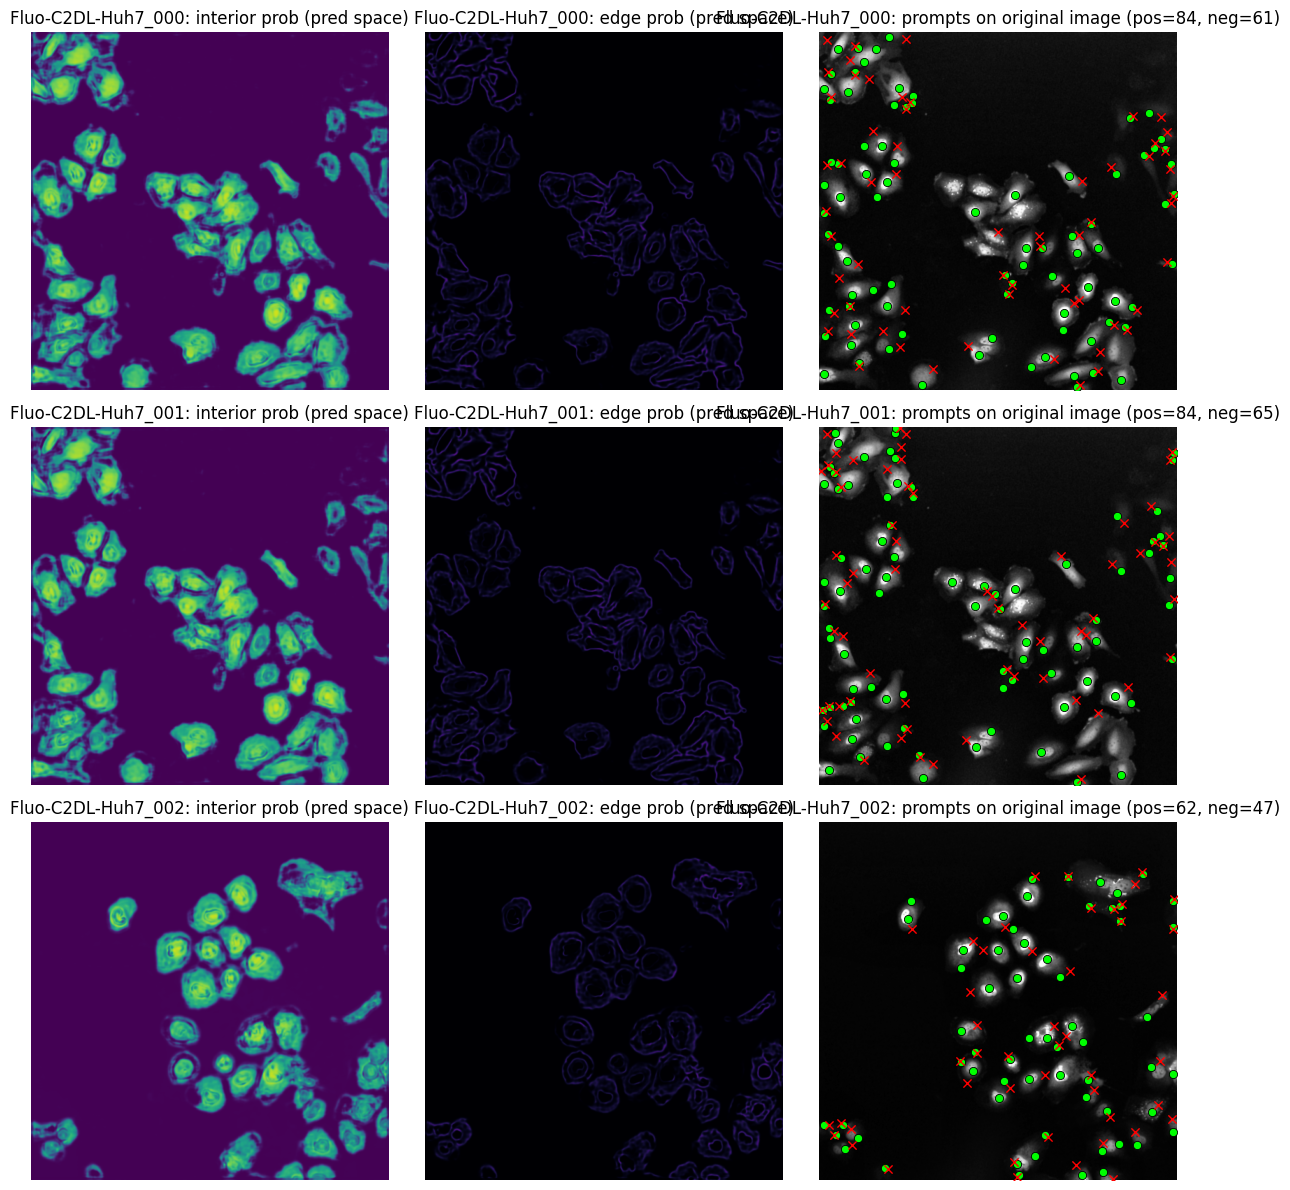

In [11]:
# Prompt generation from interior/edge predictions + point visualization
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tifffile as tiff

# Paths from previous export cell
pred_root = PROJECT_ROOT / "data" / "train_predictions" / "pred"
interior_dir = pred_root / "interior"
edge_dir = pred_root / "edge"
prompts_dir = PROJECT_ROOT / "data" / "train_predictions" / "prompts"
prompts_dir.mkdir(parents=True, exist_ok=True)

assert interior_dir.exists(), f"Missing folder: {interior_dir}"
assert edge_dir.exists(), f"Missing folder: {edge_dir}"


def point_nms(points, radius=10):
    """Simple NMS on points using euclidean distance."""
    if len(points) == 0:
        return []

    points = sorted(points, key=lambda p: p["score"], reverse=True)
    kept = []
    r2 = float(radius * radius)

    for p in points:
        keep = True
        for q in kept:
            dx = float(p["x"] - q["x"]); dy = float(p["y"] - q["y"])
            if dx * dx + dy * dy <= r2:
                keep = False
                break
        if keep:
            kept.append(p)
    return kept


def select_prompts_for_image(
    interior_prob,
    edge_prob,
    *,
    interior_thr=0.45,
    min_cell_area=20,
    max_prompts=None,
    nms_radius=10,
    extra_point_area=1200,
    extra_point_dist=20,
 ):
    """
    Adaptive multi-point strategy:
    1) one center point per connected component
    2) optional second point for large components
    3) point NMS/merge
    """
    interior_prob = interior_prob.astype(np.float32)
    edge_prob = edge_prob.astype(np.float32)

    fg = (interior_prob >= interior_thr).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(fg, connectivity=8)

    pos_points = []
    neg_points = []

    for lbl in range(1, num_labels):
        area = int(stats[lbl, cv2.CC_STAT_AREA])
        if area < min_cell_area:
            continue

        region = (labels == lbl)
        ys, xs = np.where(region)
        if len(xs) == 0:
            continue

        comp_scores = interior_prob[ys, xs]
        k = int(np.argmax(comp_scores))
        y0, x0 = int(ys[k]), int(xs[k])
        score0 = float(comp_scores[k] - 0.5 * edge_prob[y0, x0])

        pos_points.append({
            "x": x0,
            "y": y0,
            "label": 1,
            "score": score0,
            "cell_id": int(lbl),
            "kind": "primary",
        })

        if area >= extra_point_area:
            d2 = (xs - x0) ** 2 + (ys - y0) ** 2
            far = d2 >= (extra_point_dist ** 2)
            if np.any(far):
                xs_far = xs[far]
                ys_far = ys[far]
                s_far = interior_prob[ys_far, xs_far] - 0.5 * edge_prob[ys_far, xs_far]
                j = int(np.argmax(s_far))
                x1, y1 = int(xs_far[j]), int(ys_far[j])
                score1 = float(s_far[j])
                pos_points.append({
                    "x": x1,
                    "y": y1,
                    "label": 1,
                    "score": score1,
                    "cell_id": int(lbl),
                    "kind": "secondary",
                })

        ring = cv2.dilate(region.astype(np.uint8), np.ones((5, 5), np.uint8), iterations=1).astype(bool)
        ring = np.logical_and(ring, ~region)
        if np.any(ring):
            ry, rx = np.where(ring)
            edge_vals = edge_prob[ry, rx]
            m = int(np.argmax(edge_vals))
            yn, xn = int(ry[m]), int(rx[m])
            neg_points.append({
                "x": xn,
                "y": yn,
                "label": 0,
                "score": float(edge_vals[m]),
                "cell_id": int(lbl),
                "kind": "boundary_neg",
            })

    pos_points = point_nms(pos_points, radius=nms_radius)
    neg_points = point_nms(neg_points, radius=nms_radius)

    if max_prompts is not None and max_prompts > 0:
        combined = sorted(pos_points + neg_points, key=lambda p: p["score"], reverse=True)
        combined = combined[:max_prompts]
        pos_points = [p for p in combined if p["label"] == 1]
        neg_points = [p for p in combined if p["label"] == 0]

    return pos_points, neg_points


def overlay_prompts(ax, img, pos_points, neg_points, title):
    ax.imshow(img, cmap="gray")
    if len(pos_points):
        ax.scatter(
            [p["x"] for p in pos_points],
            [p["y"] for p in pos_points],
            s=35, c="lime", marker="o", edgecolors="black", linewidths=0.6, label="pos"
        )
    if len(neg_points):
        ax.scatter(
            [p["x"] for p in neg_points],
            [p["y"] for p in neg_points],
            s=35, c="red", marker="x", linewidths=1.0, label="neg"
        )
    ax.set_title(title)
    ax.axis("off")


rows = []
stems = sorted([p.stem.replace("_interior_pred", "") for p in interior_dir.glob("*_interior_pred.tif")])
assert len(stems) > 0, f"No prediction files found in {interior_dir}"

for stem in stems:
    interior_path = interior_dir / f"{stem}_interior_pred.tif"
    edge_path = edge_dir / f"{stem}_edge_pred.tif"
    img_path = IMGS_DIR / f"{stem}.tif"
    if not edge_path.exists() or not img_path.exists():
        continue

    interior_prob = tiff.imread(interior_path).astype(np.float32)
    edge_prob = tiff.imread(edge_path).astype(np.float32)
    img_orig = tiff.imread(img_path).astype(np.float32)

    pred_h, pred_w = interior_prob.shape[-2], interior_prob.shape[-1]
    orig_h, orig_w = img_orig.shape[-2], img_orig.shape[-1]
    sx = float(orig_w) / float(pred_w)
    sy = float(orig_h) / float(pred_h)

    pos_points, neg_points = select_prompts_for_image(
        interior_prob,
        edge_prob,
        interior_thr=0.3,
        min_cell_area=8,
        max_prompts=None,      # set e.g. 64 for a hard budget
        nms_radius=8,
        extra_point_area=1200,
        extra_point_dist=25,
    )

    for p in pos_points + neg_points:
        x_pred = int(p["x"]); y_pred = int(p["y"])
        x_orig = int(np.clip(round(x_pred * sx), 0, orig_w - 1))
        y_orig = int(np.clip(round(y_pred * sy), 0, orig_h - 1))
        rows.append({
            "image_stem": stem,
            "x_pred": x_pred,
            "y_pred": y_pred,
            "x_orig": x_orig,
            "y_orig": y_orig,
            "pred_w": pred_w,
            "pred_h": pred_h,
            "orig_w": orig_w,
            "orig_h": orig_h,
            "label": p["label"],   # 1=positive, 0=negative
            "score": p["score"],
            "cell_id": p["cell_id"],
            "kind": p["kind"],
        })

prompts_df = pd.DataFrame(rows).sort_values(["image_stem", "label", "score"], ascending=[True, False, False])
csv_path = prompts_dir / "cellsam_prompts_train.csv"
prompts_df.to_csv(csv_path, index=False)
print(f"Saved prompts: {csv_path} | total points: {len(prompts_df)}")
print("CSV now contains both prediction-space and original-image-space coordinates.")

# Visualization for 3 images (overlay uses ORIGINAL image coordinates)
viz_stems = stems[:3]
fig, axes = plt.subplots(len(viz_stems), 3, figsize=(12, 4 * max(1, len(viz_stems))))
if len(viz_stems) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, stem in enumerate(viz_stems):
    img_path = IMGS_DIR / f"{stem}.tif"
    interior_path = interior_dir / f"{stem}_interior_pred.tif"
    edge_path = edge_dir / f"{stem}_edge_pred.tif"

    img = tiff.imread(img_path).astype(np.float32)
    img = normalize01(img)
    interior_prob = tiff.imread(interior_path).astype(np.float32)
    edge_prob = tiff.imread(edge_path).astype(np.float32)

    sub = prompts_df[prompts_df["image_stem"] == stem]
    pos = [
        {"x": int(v.x_orig), "y": int(v.y_orig)}
        for _, v in sub[sub["label"] == 1].iterrows()
    ]
    neg = [
        {"x": int(v.x_orig), "y": int(v.y_orig)}
        for _, v in sub[sub["label"] == 0].iterrows()
    ]

    axes[r, 0].imshow(interior_prob, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[r, 0].set_title(f"{stem}: interior prob (pred space)")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(edge_prob, cmap="magma", vmin=0.0, vmax=1.0)
    axes[r, 1].set_title(f"{stem}: edge prob (pred space)")
    axes[r, 1].axis("off")

    overlay_prompts(
        axes[r, 2],
        img,
        pos,
        neg,
        title=f"{stem}: prompts on original image (pos={len(pos)}, neg={len(neg)})"
    )

plt.tight_layout()
plt.show()

Saved bump prompts: E:\cv\data\train_predictions\prompts\cellsam_prompts_train_bump.csv | total points: 3645


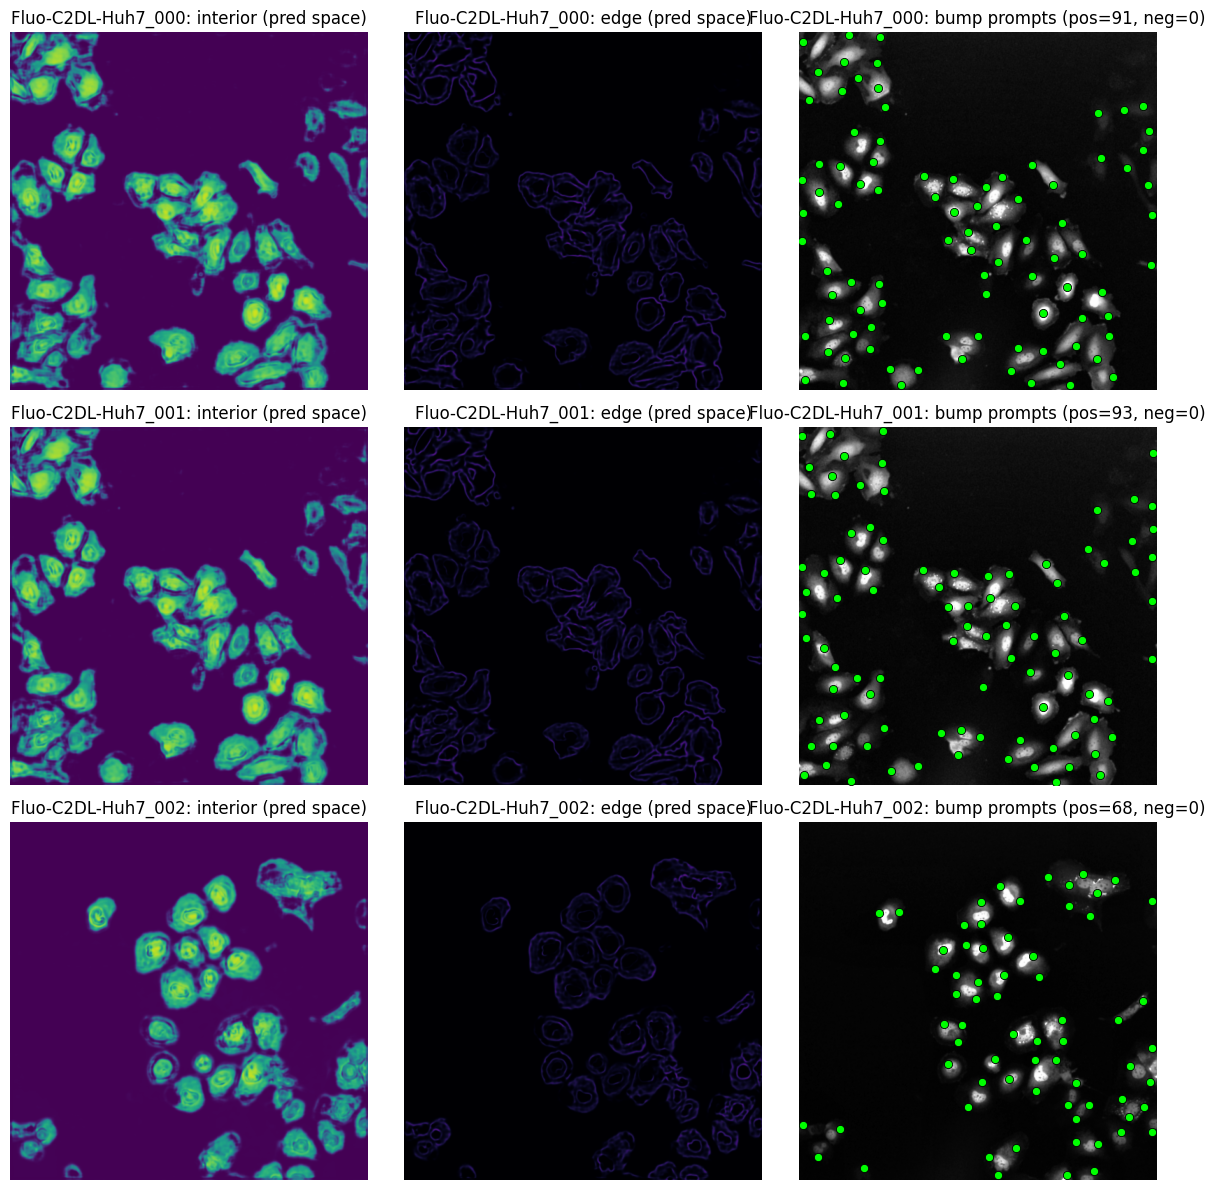

In [20]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tifffile as tiff

bump_prompts_dir = PROJECT_ROOT / "data" / "train_predictions" / "prompts"
bump_prompts_dir.mkdir(parents=True, exist_ok=True)


def bump_local_maxima(interior_prob, min_peak=0.35, blur_ksize=5):
    """Return local maxima (y, x) from smoothed interior map."""
    if blur_ksize % 2 == 0:
        blur_ksize += 1
    smooth = cv2.GaussianBlur(interior_prob.astype(np.float32), (blur_ksize, blur_ksize), 0)

    kernel = np.ones((3, 3), np.uint8)
    local_max = smooth == cv2.dilate(smooth, kernel)
    strong = smooth >= float(min_peak)
    peaks = np.logical_and(local_max, strong)

    ys, xs = np.where(peaks)
    scores = smooth[ys, xs] if len(xs) else np.array([], dtype=np.float32)
    return ys, xs, scores


def point_nms_xy(xs, ys, scores, radius=8):
    """NMS for candidate points sorted by score desc."""
    if len(xs) == 0:
        return []

    order = np.argsort(scores)[::-1]
    kept = []
    r2 = float(radius * radius)

    for idx in order:
        x = int(xs[idx]); y = int(ys[idx]); s = float(scores[idx])
        keep = True
        for p in kept:
            dx = x - p["x"]; dy = y - p["y"]
            if dx * dx + dy * dy <= r2:
                keep = False
                break
        if keep:
            kept.append({"x": x, "y": y, "score": s})
    return kept


def coverage_preserving_subset(points, keep_ratio=0.25, min_keep=6):
    """Reduce points while preserving spatial reach using farthest-point style selection."""
    n = len(points)
    if n <= min_keep:
        return points

    target = max(min_keep, int(round(n * keep_ratio)))
    if target >= n:
        return points

    pts = sorted(points, key=lambda p: p["score"], reverse=True)
    selected = [pts[0]]
    remaining = pts[1:]

    while len(selected) < target and remaining:
        best_i = 0
        best_val = -1.0
        for i, p in enumerate(remaining):
            min_d2 = float("inf")
            for q in selected:
                dx = p["x"] - q["x"]
                dy = p["y"] - q["y"]
                d2 = dx * dx + dy * dy
                if d2 < min_d2:
                    min_d2 = d2

            val = min_d2 + 4.0 * float(p["score"])
            if val > best_val:
                best_val = val
                best_i = i
        selected.append(remaining.pop(best_i))

    return selected


def generate_bump_prompts(
    interior_prob,
    edge_prob,
    max_pos=None,
    nms_radius=8,
    min_peak=0.35,
    keep_ratio=0.25,
):
    """Bump-based positives + sparse edge-based negatives."""
    ys, xs, scores = bump_local_maxima(interior_prob, min_peak=min_peak, blur_ksize=5)
    pos = point_nms_xy(xs, ys, scores, radius=nms_radius)

    if max_pos is not None and max_pos > 0:
        pos = pos[:max_pos]

    pos = coverage_preserving_subset(pos, keep_ratio=keep_ratio, min_keep=6)

    edge_s = cv2.GaussianBlur(edge_prob.astype(np.float32), (3, 3), 0)
    ey, ex = np.where(edge_s >= 0.6)
    es = edge_s[ey, ex] if len(ex) else np.array([], dtype=np.float32)
    neg_cands = point_nms_xy(ex, ey, es, radius=max(8, nms_radius))

    neg = []
    min_r2 = float((max(10, nms_radius + 2)) ** 2)
    for p in neg_cands:
        far = True
        for q in pos:
            dx = p["x"] - q["x"]; dy = p["y"] - q["y"]
            if dx * dx + dy * dy <= min_r2:
                far = False
                break
        if far:
            neg.append(p)

    max_neg = max(1, len(pos) // 3)
    neg = neg[:max_neg]
    return pos, neg


def overlay_points(ax, img, pos, neg, title):
    ax.imshow(img, cmap="gray")
    if len(pos):
        ax.scatter(
            [p["x"] for p in pos],
            [p["y"] for p in pos],
            s=35, c="lime", marker="o", edgecolors="black", linewidths=0.6
        )
    if len(neg):
        ax.scatter(
            [p["x"] for p in neg],
            [p["y"] for p in neg],
            s=35, c="red", marker="x", linewidths=1.0
        )
    ax.set_title(title)
    ax.axis("off")


def run_bump_prompt_pipeline(
    interior_dir,
    edge_dir,
    imgs_dir,
    output_csv,
    *,
    max_pos=None,
    nms_radius=8,
    min_peak=0.35,
    keep_ratio=0.67,
    show_viz=True,
    viz_count=3,
):
    """Generate bump prompts CSV and optional visualization; returns DataFrame."""
    rows = []
    stems = sorted([p.stem.replace("_interior_pred", "") for p in interior_dir.glob("*_interior_pred.tif")])
    assert len(stems) > 0, f"No prediction files found in {interior_dir}"

    for stem in stems:
        interior_path = interior_dir / f"{stem}_interior_pred.tif"
        edge_path = edge_dir / f"{stem}_edge_pred.tif"
        img_path = imgs_dir / f"{stem}.tif"
        if not edge_path.exists() or not img_path.exists():
            continue

        interior_prob = tiff.imread(interior_path).astype(np.float32)
        edge_prob = tiff.imread(edge_path).astype(np.float32)
        img = tiff.imread(img_path).astype(np.float32)

        ph, pw = interior_prob.shape[-2], interior_prob.shape[-1]
        oh, ow = img.shape[-2], img.shape[-1]
        sx = float(ow) / float(pw)
        sy = float(oh) / float(ph)

        pos_pred, neg_pred = generate_bump_prompts(
            interior_prob,
            edge_prob,
            max_pos=max_pos,
            nms_radius=nms_radius,
            min_peak=min_peak,
            keep_ratio=keep_ratio,
        )

        for p in pos_pred:
            rows.append({
                "image_stem": stem,
                "label": 1,
                "x_pred": int(p["x"]),
                "y_pred": int(p["y"]),
                "x_orig": int(np.clip(round(p["x"] * sx), 0, ow - 1)),
                "y_orig": int(np.clip(round(p["y"] * sy), 0, oh - 1)),
                "score": float(p["score"]),
                "method": "bump_maxima",
            })
        for p in neg_pred:
            rows.append({
                "image_stem": stem,
                "label": 0,
                "x_pred": int(p["x"]),
                "y_pred": int(p["y"]),
                "x_orig": int(np.clip(round(p["x"] * sx), 0, ow - 1)),
                "y_orig": int(np.clip(round(p["y"] * sy), 0, oh - 1)),
                "score": float(p["score"]),
                "method": "bump_maxima",
            })

    bump_df = pd.DataFrame(rows).sort_values(
        ["image_stem", "label", "score"],
        ascending=[True, False, False],
    )
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    bump_df.to_csv(output_csv, index=False)
    print(f"Saved bump prompts: {output_csv} | total points: {len(bump_df)}")

    if show_viz and len(bump_df) > 0:
        viz_stems = stems[:max(1, int(viz_count))]
        fig, axes = plt.subplots(len(viz_stems), 3, figsize=(12, 4 * max(1, len(viz_stems))))
        if len(viz_stems) == 1:
            axes = np.expand_dims(axes, axis=0)

        for r, stem in enumerate(viz_stems):
            img = normalize01(tiff.imread(imgs_dir / f"{stem}.tif").astype(np.float32))
            interior_prob = tiff.imread(interior_dir / f"{stem}_interior_pred.tif").astype(np.float32)
            edge_prob = tiff.imread(edge_dir / f"{stem}_edge_pred.tif").astype(np.float32)

            sub = bump_df[bump_df["image_stem"] == stem]
            pos = [{"x": int(v.x_orig), "y": int(v.y_orig)} for _, v in sub[sub["label"] == 1].iterrows()]
            neg = [{"x": int(v.x_orig), "y": int(v.y_orig)} for _, v in sub[sub["label"] == 0].iterrows()]

            axes[r, 0].imshow(interior_prob, cmap="viridis", vmin=0.0, vmax=1.0)
            axes[r, 0].set_title(f"{stem}: interior (pred space)")
            axes[r, 0].axis("off")

            axes[r, 1].imshow(edge_prob, cmap="magma", vmin=0.0, vmax=1.0)
            axes[r, 1].set_title(f"{stem}: edge (pred space)")
            axes[r, 1].axis("off")

            overlay_points(axes[r, 2], img, pos, neg, f"{stem}: bump prompts (pos={len(pos)}, neg={len(neg)})")

        plt.tight_layout()
        plt.show()

    return bump_df


bump_csv = bump_prompts_dir / "cellsam_prompts_train_bump.csv"
bump_df = run_bump_prompt_pipeline(
    interior_dir=interior_dir,
    edge_dir=edge_dir,
    imgs_dir=IMGS_DIR,
    output_csv=bump_csv,
    max_pos=None,
    nms_radius=8,
    min_peak=0.35,
    keep_ratio=0.25,
    show_viz=True,
    viz_count=3,
)

In [ ]:
# Prompt-based SAM inference using CNN prompt CSV + edge-guided mask cutting
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd
import cv2
import tifffile as tiff
import matplotlib.pyplot as plt
import torch

try:
    from segment_anything import sam_model_registry, SamPredictor
except ImportError as e:
    raise ImportError(
        "segment-anything is required. Install with: pip install git+https://github.com/facebookresearch/segment-anything.git"
    ) from e


# 1) Paths

pred_root = PROJECT_ROOT / "data" / "train_predictions" / "pred"
pred_edge_dir = pred_root / "edge"
out_root = PROJECT_ROOT / "data" / "sam_prompt_outputs"
raw_dir = out_root / "raw_instances"
cut_dir = out_root / "cut_instances"
viz_dir = out_root / "viz"
raw_dir.mkdir(parents=True, exist_ok=True)
cut_dir.mkdir(parents=True, exist_ok=True)
viz_dir.mkdir(parents=True, exist_ok=True)

prompts_dir = PROJECT_ROOT / "data" / "train_predictions" / "prompts"
bump_prompts_csv = prompts_dir / "cellsam_prompts_train_bump.csv"
base_prompts_csv = prompts_dir / "cellsam_prompts_train.csv"

if bump_prompts_csv.exists():
    sam_prompts_csv = bump_prompts_csv
elif base_prompts_csv.exists():
    sam_prompts_csv = base_prompts_csv
else:
    raise FileNotFoundError(
        f"No prompt CSV found in {prompts_dir}. Run prompt generation first (Cell 13)."
    )

prompts_df = pd.read_csv(sam_prompts_csv)
required_cols = {"image_stem", "label", "x_orig", "y_orig"}
if not required_cols.issubset(set(prompts_df.columns)):
    raise RuntimeError(
        f"Prompt CSV missing required columns {required_cols}. Found: {list(prompts_df.columns)}"
    )
print(f"Using CNN prompts from: {sam_prompts_csv} (rows={len(prompts_df)})")

# 2) Load normal SAM checkpoint

model_dir = PROJECT_ROOT / ".model"
model_dir.mkdir(parents=True, exist_ok=True)

def infer_sam_model_type(ckpt_path: Path) -> str:
    name = ckpt_path.name.lower()
    if "vit_h" in name:
        return "vit_h"
    if "vit_l" in name:
        return "vit_l"
    return "vit_b"

def is_likely_html(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            head = f.read(32).lstrip()
        return head.startswith(b"<")
    except Exception:
        return True

sam_ckpt_candidates = sorted(list(model_dir.glob("sam_vit_*.pth")) + list(PROJECT_ROOT.glob("sam_vit_*.pth")))
valid_candidates = [p for p in sam_ckpt_candidates if p.exists() and p.stat().st_size > 1024 and not is_likely_html(p)]

if len(valid_candidates) == 0:
    sam_ckpt = model_dir / "sam_vit_b_01ec64.pth"
    sam_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
    print(f"Downloading SAM checkpoint from {sam_url} to {sam_ckpt}")
    urllib.request.urlretrieve(sam_url, str(sam_ckpt))
    if is_likely_html(sam_ckpt):
        raise RuntimeError(
            f"Downloaded file at {sam_ckpt} is not a valid SAM checkpoint (looks like HTML)."
        )
else:
    sam_ckpt = valid_candidates[0]

sam_model_type = infer_sam_model_type(sam_ckpt)
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[sam_model_type](checkpoint=None)
with open(sam_ckpt, "rb") as f:
    state_dict = torch.load(f, map_location="cpu", weights_only=False)
sam.load_state_dict(state_dict)
sam.to(device=device)
predictor = SamPredictor(sam)
print(f"Loaded normal SAM checkpoint: {sam_ckpt} (model_type={sam_model_type}, device={device})")

# 3) Utilities

def normalize01(x):
    x = x.astype(np.float32)
    lo, hi = float(x.min()), float(x.max())
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)


def masks_to_instance_map(masks, shape_hw):
    h, w = shape_hw
    inst = np.zeros((h, w), dtype=np.int32)
    for idx, m in enumerate(masks, start=1):
        inst[m.astype(bool)] = idx
    return inst


def relabel_by_area(label_img, min_area=20):
    num, cc = cv2.connectedComponents((label_img > 0).astype(np.uint8), connectivity=8)
    out = np.zeros_like(label_img, dtype=np.int32)
    nxt = 1
    for k in range(1, num):
        m = (cc == k)
        if int(m.sum()) < min_area:
            continue
        out[m] = nxt
        nxt += 1
    return out


def edge_guided_cut(instance_map, edge_prob, edge_thr=0.45, min_piece_area=20, edge_dilate_iters=3):
    h, w = instance_map.shape
    out = np.zeros((h, w), dtype=np.int32)
    next_id = 1

    barrier = (edge_prob >= edge_thr).astype(np.uint8)
    if edge_dilate_iters > 0:
        barrier = cv2.dilate(barrier, np.ones((3, 3), np.uint8), iterations=int(edge_dilate_iters))
    barrier = barrier.astype(bool)

    for obj_id in np.unique(instance_map):
        if obj_id == 0:
            continue
        obj = (instance_map == obj_id)
        if int(obj.sum()) < min_piece_area:
            continue

        core = np.logical_and(obj, ~barrier).astype(np.uint8)
        if int(core.sum()) < min_piece_area:
            out[obj] = next_id
            next_id += 1
            continue

        dist = cv2.distanceTransform(core, cv2.DIST_L2, 3)
        dist_u8 = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, peaks = cv2.threshold(dist_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        peaks = cv2.morphologyEx(peaks, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

        num_mark, markers = cv2.connectedComponents(peaks)
        if num_mark <= 1:
            out[obj] = next_id
            next_id += 1
            continue

        ws_img = np.stack([dist_u8, dist_u8, dist_u8], axis=-1)
        markers = markers.astype(np.int32)
        markers[~obj] = 0
        markers = cv2.watershed(ws_img, markers)

        kept_any_piece = False
        for m_id in np.unique(markers):
            if m_id <= 0:
                continue
            piece = np.logical_and(markers == m_id, obj)
            if int(piece.sum()) < min_piece_area:
                continue
            out[piece] = next_id
            next_id += 1
            kept_any_piece = True

        if not kept_any_piece:
            out[obj] = next_id
            next_id += 1

    return out


def prompt_points_for_stem(stem, h, w, prompts_table):
    sub = prompts_table[(prompts_table["image_stem"] == stem) & (prompts_table["label"] == 1)]
    if len(sub) == 0:
        return np.empty((0, 2), dtype=np.float32)

    pts = sub[["x_orig", "y_orig"]].to_numpy(dtype=np.float32)
    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)

    if len(pts) > 1:
        pts = np.unique(np.round(pts).astype(np.int32), axis=0).astype(np.float32)
    return pts


# 4) Run prompt-based SAM on 3 images using CNN prompts
all_pairs = getattr(base_ds, "pairs", [])
if len(all_pairs) == 0:
    raise RuntimeError("No image/mask pairs found in base_ds.")

max_images = 3
EDGE_THR = 0.45
EDGE_DILATE_ITERS = 3
MIN_PIECE_AREA = 10
FINAL_MIN_AREA = 10
run_pairs = all_pairs[:max_images]
print(f"Running prompt-based SAM on {len(run_pairs)} image(s) (max_images={max_images})")

num_no_prompts = 0
num_no_masks = 0

for img_path, _mask_path in run_pairs:
    stem = img_path.stem
    img = tiff.imread(img_path).astype(np.float32)

    img_norm = normalize01(img)
    img_u8 = (img_norm * 255.0).clip(0, 255).astype(np.uint8)
    img_rgb = np.stack([img_u8] * 3, axis=-1)

    prompt_points = prompt_points_for_stem(stem, img_u8.shape[0], img_u8.shape[1], prompts_df)

    if len(prompt_points) == 0:
        num_no_prompts += 1
        raw_inst = np.zeros_like(img_u8, dtype=np.int32)
        cut_inst = raw_inst.copy()
    else:
        predictor.set_image(img_rgb)
        all_masks = []

        for pt in prompt_points:
            point_coords = np.array([pt], dtype=np.float32)
            point_labels = np.array([1], dtype=np.int32)

            masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True,
            )

            best_idx = int(np.argmax(scores))
            best_mask = masks[best_idx]
            all_masks.append(best_mask)

        if len(all_masks) == 0:
            num_no_masks += 1
            raw_inst = np.zeros_like(img_u8, dtype=np.int32)
        else:
            raw_inst = masks_to_instance_map(all_masks, img_u8.shape)
            raw_inst = relabel_by_area(raw_inst, min_area=FINAL_MIN_AREA)

        edge_path = pred_edge_dir / f"{stem}_edge_pred.tif"
        if edge_path.exists() and raw_inst.max() > 0:
            edge_prob = tiff.imread(edge_path).astype(np.float32)
            if edge_prob.shape != raw_inst.shape:
                edge_prob = cv2.resize(edge_prob, (raw_inst.shape[1], raw_inst.shape[0]), interpolation=cv2.INTER_LINEAR)
            cut_inst = edge_guided_cut(
                raw_inst,
                edge_prob,
                edge_thr=EDGE_THR,
                min_piece_area=MIN_PIECE_AREA,
                edge_dilate_iters=EDGE_DILATE_ITERS,
            )
            cut_inst = relabel_by_area(cut_inst, min_area=FINAL_MIN_AREA)
        else:
            cut_inst = raw_inst.copy()

    tiff.imwrite(raw_dir / f"{stem}_raw_instances.tif", raw_inst.astype(np.int32))
    tiff.imwrite(cut_dir / f"{stem}_cut_instances.tif", cut_inst.astype(np.int32))

    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(img_u8, cmap="gray")
    if len(prompt_points) > 0:
        ax1.scatter(prompt_points[:, 0], prompt_points[:, 1], c="yellow", s=12)
    ax1.set_title(f"{stem}: prompts={len(prompt_points)}")
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(img_u8, cmap="gray")
    if raw_inst.max() > 0:
        rng = np.random.default_rng(42)
        overlay = np.zeros((img_u8.shape[0], img_u8.shape[1], 4), dtype=np.float32)
        for obj_id in np.unique(raw_inst):
            if obj_id == 0:
                continue
            color = rng.random(3)
            overlay[raw_inst == obj_id, :3] = color
            overlay[raw_inst == obj_id, 3] = 0.35
        ax2.imshow(overlay)
    ax2.set_title(f"{stem}: raw SAM instances={int(raw_inst.max())}")
    ax2.axis("off")

    fig.tight_layout()
    fig.savefig(viz_dir / f"{stem}_sam_prompt_viz.png", dpi=140)
    plt.close(fig)

print(f"Saved raw SAM instances to: {raw_dir}")
print(f"Saved edge-cut instances to: {cut_dir}")
print(f"Saved visualizations to: {viz_dir}")
print(f"Images with zero prompt points: {num_no_prompts}")
print(f"Images with zero SAM masks from prompts: {num_no_masks}")

Using CNN prompts from: E:\cv\data\train_predictions\prompts\cellsam_prompts_train_bump.csv (rows=3645)
Loaded normal SAM checkpoint: E:\cv\.model\sam_vit_b_01ec64.pth (model_type=vit_b, device=cuda)
Running prompt-based SAM on 3 image(s) (max_images=3)
Saved raw SAM instances to: E:\cv\data\sam_prompt_outputs\raw_instances
Saved edge-cut instances to: E:\cv\data\sam_prompt_outputs\cut_instances
Saved visualizations to: E:\cv\data\sam_prompt_outputs\viz
Images with zero prompt points: 0
Images with zero SAM masks from prompts: 0


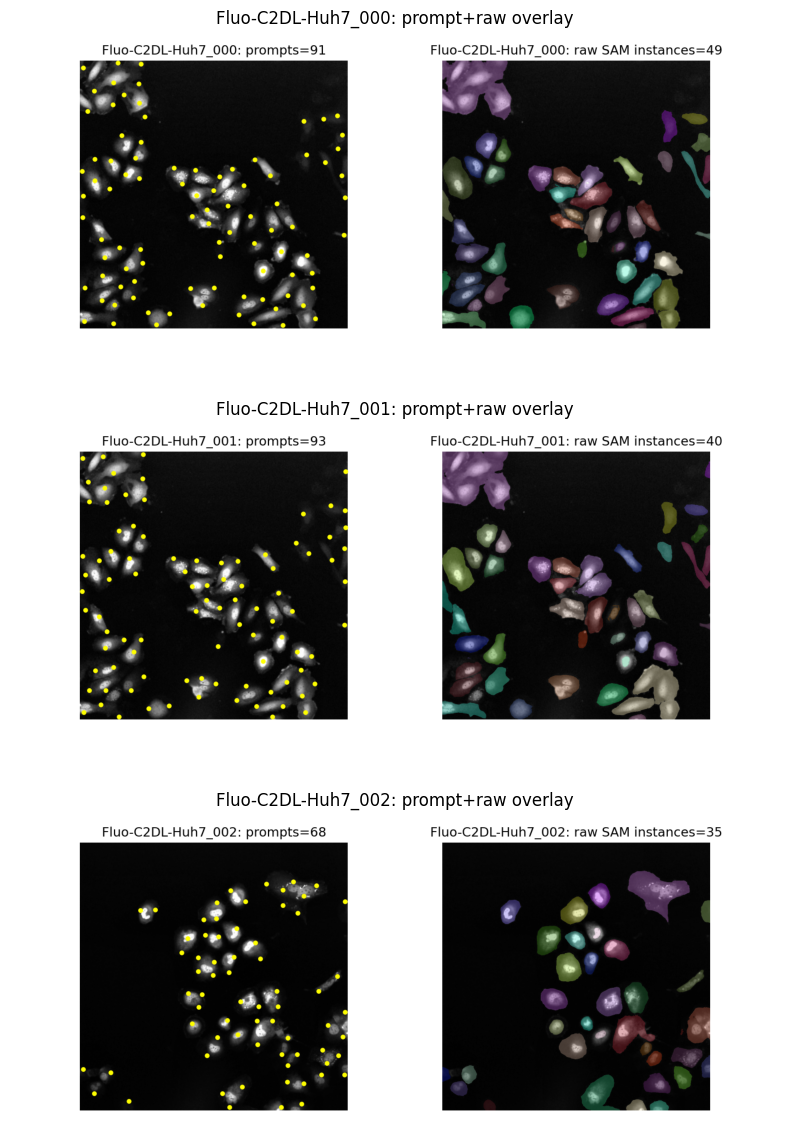

In [47]:
# Visualize saved SAM prompt outputs (left pair only)
import numpy as np
import matplotlib.pyplot as plt

viz_dir = PROJECT_ROOT / "data" / "sam_prompt_outputs" / "viz"

viz_paths = sorted(viz_dir.glob("*_sam_prompt_viz.png"))[:3]
if len(viz_paths) == 0:
    raise RuntimeError(f"No visualization images found in {viz_dir}. Run Cell 14 first.")

fig, axes = plt.subplots(len(viz_paths), 1, figsize=(8, 4 * len(viz_paths)))
if len(viz_paths) == 1:
    axes = np.array([axes])

for r, vp in enumerate(viz_paths):
    stem = vp.name.replace("_sam_prompt_viz.png", "")
    viz_img = plt.imread(vp)

    axes[r].imshow(viz_img)
    axes[r].set_title(f"{stem}: prompt+raw overlay")
    axes[r].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def calculate_seg_score(pred_masks, gt_seg_masks, iou_threshold=0.5):
    ious = []
    thr = float(iou_threshold)

    for p_mask, g_mask in zip(pred_masks, gt_seg_masks):
        g_ids = np.unique(g_mask[g_mask > 0])
        if len(g_ids) == 0:
            continue

        for gid in g_ids:
            target = (g_mask == gid)
            best_iou = 0.0

            # Only evaluate predicted instances that overlap this GT object.
            overlapping_p_ids = np.unique(p_mask[target])
            for pid in overlapping_p_ids:
                if pid == 0:
                    continue
                pred = (p_mask == pid)
                inter = np.logical_and(target, pred).sum()
                union = np.logical_or(target, pred).sum()
                if union == 0:
                    continue
                iou = inter / union
                if iou > best_iou:
                    best_iou = iou

            ious.append(best_iou if best_iou >= thr else 0.0)

    return float(np.mean(ious)) if ious else 0.0

In [ ]:
# Full-train-set inference + SEG metric evaluation (raw and edge-cut)
import numpy as np
import tifffile as tiff

run_pairs = list(all_pairs)
print(f"Running full training set: {len(run_pairs)} image(s)")

pred_raw_masks = []
pred_cut_masks = []
gt_seg_masks = []
num_no_prompts = 0
num_no_masks = 0

for img_path, mask_path in run_pairs:
    stem = img_path.stem
    img = tiff.imread(img_path).astype(np.float32)
    gt_mask = tiff.imread(mask_path).astype(np.int32)

    img_norm = normalize01(img)
    img_u8 = (img_norm * 255.0).clip(0, 255).astype(np.uint8)
    img_rgb = np.stack([img_u8] * 3, axis=-1)

    prompt_points = prompt_points_for_stem(stem, img_u8.shape[0], img_u8.shape[1], prompts_df)

    if len(prompt_points) == 0:
        num_no_prompts += 1
        raw_inst = np.zeros_like(img_u8, dtype=np.int32)
        cut_inst = raw_inst.copy()
    else:
        predictor.set_image(img_rgb)
        all_masks_local = []

        for pt in prompt_points:
            point_coords = np.array([pt], dtype=np.float32)
            point_labels = np.array([1], dtype=np.int32)
            masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True,
            )
            best_idx = int(np.argmax(scores))
            all_masks_local.append(masks[best_idx])

        if len(all_masks_local) == 0:
            num_no_masks += 1
            raw_inst = np.zeros_like(img_u8, dtype=np.int32)
        else:
            raw_inst = masks_to_instance_map(all_masks_local, img_u8.shape)
            raw_inst = relabel_by_area(raw_inst, min_area=FINAL_MIN_AREA)

        edge_path = pred_edge_dir / f"{stem}_edge_pred.tif"
        if edge_path.exists() and raw_inst.max() > 0:
            edge_prob = tiff.imread(edge_path).astype(np.float32)
            if edge_prob.shape != raw_inst.shape:
                edge_prob = cv2.resize(
                    edge_prob,
                    (raw_inst.shape[1], raw_inst.shape[0]),
                    interpolation=cv2.INTER_LINEAR,
                )
            cut_inst = edge_guided_cut(
                raw_inst,
                edge_prob,
                edge_thr=EDGE_THR,
                min_piece_area=MIN_PIECE_AREA,
                edge_dilate_iters=EDGE_DILATE_ITERS,
            )
            cut_inst = relabel_by_area(cut_inst, min_area=FINAL_MIN_AREA)
        else:
            cut_inst = raw_inst.copy()

    tiff.imwrite(raw_dir / f"{stem}_raw_instances.tif", raw_inst.astype(np.int32))
    tiff.imwrite(cut_dir / f"{stem}_cut_instances.tif", cut_inst.astype(np.int32))

    pred_raw_masks.append(raw_inst)
    pred_cut_masks.append(cut_inst)
    gt_seg_masks.append(gt_mask)

seg_raw = calculate_seg_score(pred_raw_masks, gt_seg_masks)
seg_cut = calculate_seg_score(pred_cut_masks, gt_seg_masks)

print(f"Processed training images: {len(run_pairs)}")
print(f"Images with zero prompt points: {num_no_prompts}")
print(f"Images with zero SAM masks from prompts: {num_no_masks}")
print(f"SEG (raw SAM instances): {seg_raw:.6f}")
print(f"SEG (edge-cut instances): {seg_cut:.6f}")

Running full training set: 127 image(s)
Processed training images: 127
Images with zero prompt points: 25
Images with zero SAM masks from prompts: 0
SEG (raw SAM instances): 0.199222
SEG (edge-cut instances): 0.198907


In [ ]:
# Recompute SEG from cached predictions with updated evaluation
if not all(k in globals() for k in ["pred_raw_masks", "pred_cut_masks", "gt_seg_masks"]):
    raise RuntimeError("Missing cached predictions. Run Cell 17 first.")

seg_raw = calculate_seg_score(pred_raw_masks, gt_seg_masks, iou_threshold=0.5)
seg_cut = calculate_seg_score(pred_cut_masks, gt_seg_masks, iou_threshold=0.5)

print(f"Updated SEG (raw SAM instances): {seg_raw:.6f}")
print(f"Updated SEG (edge-cut instances): {seg_cut:.6f}")
print(f"Evaluated GT masks: {len(gt_seg_masks)}")